# Kafka + Spark Structured Streaming

Kafka can be integrated relatively easily with the streaming APIs of Spark to act as either a `source` or a `sink` for the streaming data.

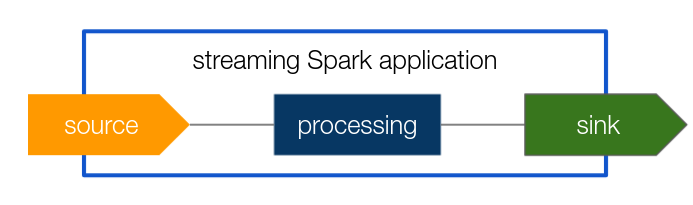

We'll reproduce the PySpark example we discussed when testing the `Structured Streaming`, now interfacing both the `source` and the `sink` of Spark with Kafka topics.

In [1]:
# define the list of brokers in the cluster
KAFKA_BOOTSTRAP_SERVERS = 'kafka-broker:9092'

In [2]:
import os
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("spark://spark-master:7077")\
    .appName("Spark structured streaming application")\
    .config("spark.executor.memory", "512m")\
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")\
    .config("spark.sql.adaptive.enabled", "false")\
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "false")\
    .config("spark.sql.shuffle.partitions", 4)\
    .config("spark.jars.packages","org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.5")\
    .getOrCreate()

:: loading settings :: url = jar:file:/usr/bin/spark-3.5.5-bin-hadoop3/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-b34b47b4-b505-499f-b55d-305331074faf;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.5.5 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.5.5 in central
	found org.apache.kafka#kafka-clients;3.4.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.10.5 in central
	found org.slf4j#slf4j-api;2.0.7 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.4 in central
	found org.apache.hadoop#hadoop-client-api;3.3.4 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central
downloading https://repo1.maven.org/maven2/org/apache/spark/spark-sql-kafka-

In [3]:
sc = spark.sparkContext
sc

<SparkContext master=spark://spark-master:7077 appName=Spark structured streaming application>

## Read data from Kafka

First, we create a DataFrame representing the stream of input lines from Kafka by connecting to the appropriate servers and topic.

`readStream` and `format("kafka")` are the key components for connecting to the data source.

In [4]:
rawMessagesDf = spark\
    .readStream\
    .format("kafka")\
    .option("kafka.bootstrap.servers", KAFKA_BOOTSTRAP_SERVERS)\
    .option("kafkaConsumer.pollTimeoutMs", 4000)\
    .option("startingOffsets", "latest") \
    .option("subscribe", "a_partitioned_topic")\
    .option("failOnDataLoss", "false")\
    .load()    

At this stage, nothing happens because the streaming has not started yet. We have only defined the source of the streaming application.

The `rawMessagesDf` can be treated as if it were a static DataFrame in Spark, **but** it is a streaming DataFrame that continuously grows.

In [5]:
rawMessagesDf.isStreaming

True

Currently, `rawMessagesDf` contains the messages from Kafka, which are further composed of a `<key, value>` pair, a timestamp, and other information.

In [6]:
rawMessagesDf.printSchema()

root
 |-- key: binary (nullable = true)
 |-- value: binary (nullable = true)
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- timestampType: integer (nullable = true)



We are clearly interested in the `value` of the message, which is in JSON format.

We can utilize the `pyspark.sql` functions to define a schema for our structured data and interpret the data accordingly.

In [7]:
from pyspark.sql.functions import from_json, col
from pyspark.sql.types import StructField, StructType, StringType, DoubleType, IntegerType

# the schema of the json data format used to create the messages
schema = StructType(
        [
                StructField("name", StringType()),
                StructField("surname", StringType()),
                StructField("amount", DoubleType()),
                StructField("delta_t", DoubleType()),
                StructField("flag", IntegerType())
        ]
)

# a new DF can be created from the previous by using the pyspark.sql functions
parsedDf = (
    rawMessagesDf
    .select(
        from_json(col("value").alias("value").cast("string"), schema)
        .alias("data")
    )
    .select(col("data.*"))
)

In [8]:
parsedDf.printSchema()

root
 |-- name: string (nullable = true)
 |-- surname: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- delta_t: double (nullable = true)
 |-- flag: integer (nullable = true)



It's possible to inspect the data actually reaching the `parsedDf` by starting a stream with a `console` sink. 
The output of the streaming processing in this case will be displayed in the shell running the Jupyter Notebook.

We should expect a DataFrame with a single column, containing a JSON-like object per message.

In [10]:
query = (
    parsedDf.writeStream\
            .outputMode("append")\
            .format("console")\
            .start()
)

25/05/29 08:11:05 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-cb533732-8da3-4146-8bef-839dcb37ee70. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
25/05/29 08:11:05 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.
                                                                                

-------------------------------------------
Batch: 1
-------------------------------------------
-------------------------------------------
Batch: 0
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
+----+-------+------+-------+----+

-------------------------------------------
Batch: 1
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
|John|Johnson|243.92|   6.87|   0|
| Joe|Johnson|304.93|   8.98|   0|
+----+-------+------+-------+----+

+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
|Andy|  Jones|222.98|   4.21|   0|
+----+-------+------+-------+----+



-------------------------------------------
Batch: 2
-------------------------------------------
+-----+-------+------+-------+----+
| name|surname|amount|delta_t|flag|
+-----+-------+------+-------+----+
|Alice|Millers|716.56|   7.03|   0|
|Alice|  Jones|469.26|   2.35|   0|
+-----+-------+------+-------+----+



-------------------------------------------
Batch: 2
-------------------------------------------
+-----+-------+------+-------+----+
| name|surname|amount|delta_t|flag|
+-----+-------+------+-------+----+
|Alice|Millers|133.48|   1.25|   0|
|Alice|Millers|119.43|   5.44|   0|
| Andy|  Jones| 948.7|   5.36|   0|
| John|  Smith|823.46|   4.36|   0|
| John|Millers|914.36|   1.61|   0|
|  Joe|  Smith|  5.36|    3.9|   0|
| John|Millers|524.53|   5.01|   0|
| Andy|Johnson|673.56|   7.28|   0|
| John|Johnson|352.61|   1.54|   0|
| Andy|  Smith|672.47|   2.17|   0|
|  Joe|  Smith|613.03|   3.15|   1|
|  Joe|Millers|817.84|   3.46|   0|
| John|Johnson| 376.6|   4.55|   0|
|Alice|  Smith|748.56|   1.67|   0|
|  Joe|Johnson| 97.45|    6.4|   0|
| John|Johnson|243.92|   6.87|   0|
|  Joe|Johnson|304.93|   8.98|   0|
|Alice|Millers|716.56|   7.03|   0|
|Alice|  Jones|469.26|   2.35|   0|
+-----+-------+------+-------+----+



In [11]:
query.stop()

## Simple Fraud Detection + Kafka Sink

Let's integrate the same simplistic "fraud detection" logic we previously used in our Spark Streaming example.

We might be interested in having Spark perform the heavy lifting and then allowing other consumers to access the results of these operations. For example, we can display the results on a dashboard or trigger some action.

We can use Kafka as a sink for the resulting data.

In [12]:
from pyspark.sql.functions import concat, col, lit, countDistinct

# find number of transactions for each user when flag = 1 
num_transactions = parsedDf \
    .where(col('flag')==1) \
    .withColumn('id', concat(col('name'), col('surname'))) \
    .groupBy('id') \
    .count() 
    
# find suspicious transactions
sus_transactions = num_transactions \
    .where(col('count')>1) \
    .withColumn('fraud', lit(1)) \
    .select(col("id").alias("key"),
            col("fraud").cast(StringType()).alias("value"))

At this point, it may seem that these newly derived DataFrames are not connected in any way or form to the input streaming Kafka source.

However, we can verify this by using the `isStreaming` method on a DataFrame.

In [13]:
sus_transactions.isStreaming

True

In [14]:
sus_transactions.printSchema()

root
 |-- key: string (nullable = true)
 |-- value: string (nullable = false)



The `sus_transactions` DataFrame is still a streaming DataFrame. It can be seen as the result of the transformations applied to the original `inputDF` derived from the streaming source.

In [15]:
query = (
    sus_transactions.writeStream\
                    .outputMode("update")\
                    .format("console")\
                    .start()
)

25/05/29 08:12:17 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-a267fde6-32ad-41c7-abb5-943e29362c16. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
25/05/29 08:12:17 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.
                                                                                

-------------------------------------------
Batch: 0
-------------------------------------------
+---+-----+
|key|value|
+---+-----+
+---+-----+

-------------------------------------------
Batch: 3
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
| Joe|Millers|939.11|   2.21|   1|
+----+-------+------+-------+----+



-------------------------------------------
Batch: 4
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
|Andy|Millers|981.59|   0.27|   0|
|Andy|Johnson| 899.7|   5.49|   1|
+----+-------+------+-------+----+



[Stage 10:===========================================>              (3 + 1) / 4]

In [ ]:
query.stop()

Finally, let's wrap up the message and write it to a `results` topic back to Kafka, so that other consumers can make use of its data.

In [16]:
query = (
    sus_transactions.writeStream\
                    .outputMode("update")\
                    .format("kafka") \
                    .option("kafka.bootstrap.servers", KAFKA_BOOTSTRAP_SERVERS) \
                    .option("topic", "results") \
                    .option("checkpointLocation", "checkpoint") \
                    .option("failOnDataLoss", "false") \
                    .start()
)

-------------------------------------------
Batch: 1
-------------------------------------------
+---+-----+
|key|value|
+---+-----+
+---+-----+



25/05/29 08:14:44 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.


-------------------------------------------
Batch: 5
-------------------------------------------
+-----+-------+------+-------+----+
| name|surname|amount|delta_t|flag|
+-----+-------+------+-------+----+
| Andy|  Smith|468.44|   1.26|   0|
|Alice|  Smith|397.42|   4.64|   0|
| Andy|Millers|916.05|   6.39|   0|
|Alice|  Smith|717.84|   8.77|   1|
| Andy|  Smith|222.02|   3.04|   0|
+-----+-------+------+-------+----+



-------------------------------------------
Batch: 6
-------------------------------------------
+-----+-------+------+-------+----+
| name|surname|amount|delta_t|flag|
+-----+-------+------+-------+----+
|  Joe|Johnson|941.13|   7.31|   0|
|Alice|Millers| 52.07|   2.97|   0|
|Alice|Millers|671.11|   2.76|   0|
| Andy|  Smith|734.95|   6.17|   0|
|Alice|Johnson|392.37|   0.74|   0|
+-----+-------+------+-------+----+



-------------------------------------------
Batch: 2
-------------------------------------------
+---+-----+
|key|value|
+---+-----+
+---+-----+



-------------------------------------------
Batch: 7
-------------------------------------------
+-----+-------+------+-------+----+
| name|surname|amount|delta_t|flag|
+-----+-------+------+-------+----+
| John|Johnson|179.47|   9.76|   0|
|  Joe|Johnson|438.69|   8.88|   0|
|Alice|Johnson| 513.5|    6.8|   0|
| John|  Smith|264.88|   9.21|   0|
| John|Millers|621.46|   6.05|   1|
| Andy|Millers|512.18|   1.77|   0|
+-----+-------+------+-------+----+



-------------------------------------------
Batch: 3
-------------------------------------------
+---+-----+
|key|value|
+---+-----+
+---+-----+

-------------------------------------------
Batch: 8
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
|Andy|Millers|960.36|   5.55|   0|
+----+-------+------+-------+----+



In [17]:
query.stop()

-------------------------------------------
Batch: 9
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
|Andy|  Jones|670.97|   9.73|   0|
+----+-------+------+-------+----+



-------------------------------------------
Batch: 10
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
|John|Millers|698.11|    5.8|   1|
+----+-------+------+-------+----+

-------------------------------------------
Batch: 4
-------------------------------------------
+---+-----+
|key|value|
+---+-----+
+---+-----+

-------------------------------------------
Batch: 11
-------------------------------------------
+-----+-------+------+-------+----+
| name|surname|amount|delta_t|flag|
+-----+-------+------+-------+----+
| John|Millers|397.58|   7.79|   0|
|  Joe|Millers|147.98|   5.93|   1|
|Alice|Millers|550.71|   4.45|   1|
| John|  Jones| 332.0|   8.58|   0|
+-----+-------+------+-------+----+



-------------------------------------------
Batch: 12
-------------------------------------------
+-----+-------+------+-------+----+
| name|surname|amount|delta_t|flag|
+-----+-------+------+-------+----+
|Alice|Johnson|751.33|    6.8|   0|
|Alice|Millers|219.38|   9.74|   0|
|Alice|  Jones| 66.02|   8.52|   0|
| John|  Jones|664.41|   2.52|   0|
+-----+-------+------+-------+----+



-------------------------------------------
Batch: 5
-------------------------------------------
+-----------+-----+
|        key|value|
+-----------+-----+
|JohnMillers|    1|
| JoeMillers|    1|
+-----------+-----+

-------------------------------------------
Batch: 13
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
|Andy|  Smith|874.81|   7.99|   0|
| Joe|Johnson| 45.98|   4.16|   0|
|Andy|Millers|938.78|   1.14|   0|
+----+-------+------+-------+----+



-------------------------------------------
Batch: 14
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
|Andy|  Jones|409.26|   9.95|   0|
| Joe|  Jones| 15.04|   2.39|   1|
| Joe|Millers|251.49|   8.34|   1|
|Andy|Millers|230.07|   5.28|   0|
+----+-------+------+-------+----+

-------------------------------------------
Batch: 6
-------------------------------------------
+----------+-----+
|       key|value|
+----------+-----+
|JoeMillers|    1|
+----------+-----+



...

-------------------------------------------
Batch: 137
-------------------------------------------
+-----+-------+------+-------+----+
| name|surname|amount|delta_t|flag|
+-----+-------+------+-------+----+
|Alice|Millers|877.38|   6.76|   1|
| John|Johnson|463.96|   4.24|   0|
+-----+-------+------+-------+----+

-------------------------------------------
Batch: 63
-------------------------------------------
+------------+-----+
|         key|value|
+------------+-----+
|AliceMillers|    1|
+------------+-----+

-------------------------------------------
Batch: 138
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
|Andy|Millers|649.82|    4.0|   0|
|Andy|Millers|192.64|   6.82|   0|
|Andy|  Jones| 11.38|   1.28|   0|
+----+-------+------+-------+----+



-------------------------------------------
Batch: 139
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
|Andy|Johnson|748.14|   7.28|   0|
| Joe|  Smith|345.38|   1.67|   0|
|John|  Smith|140.56|   5.58|   0|
+----+-------+------+-------+----+

-------------------------------------------
Batch: 64
-------------------------------------------
+---+-----+
|key|value|
+---+-----+
+---+-----+



-------------------------------------------
Batch: 140
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
|John|Millers|131.52|   8.03|   0|
| Joe|  Jones|409.22|   0.46|   0|
|Andy|Millers| 94.77|   6.26|   0|
+----+-------+------+-------+----+



-------------------------------------------
Batch: 141
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
| Joe|Millers|234.01|   5.98|   0|
| Joe|Millers|567.67|   8.88|   0|
|John|Millers|999.51|   1.51|   1|
+----+-------+------+-------+----+

-------------------------------------------
Batch: 65
-------------------------------------------
+---+-----+
|key|value|
+---+-----+
+---+-----+

-------------------------------------------
Batch: 142
-------------------------------------------
+----+-------+------+-------+----+
|name|surname|amount|delta_t|flag|
+----+-------+------+-------+----+
|Andy|Johnson|655.53|   7.86|   1|
| Joe|Johnson| 66.08|   5.89|   0|
|John|Millers|620.55|   1.95|   0|
| Joe|  Smith| 32.67|   7.93|   0|
+----+-------+------+-------+----+



-------------------------------------------
Batch: 143
-------------------------------------------
+-----+-------+------+-------+----+
| name|surname|amount|delta_t|flag|
+-----+-------+------+-------+----+
|  Joe|Johnson| 15.52|   2.06|   0|
|Alice|  Jones|750.91|   4.48|   1|
| Andy|  Smith|179.91|   3.99|   0|
+-----+-------+------+-------+----+

-------------------------------------------
Batch: 66
-------------------------------------------
+-----------+-----+
|        key|value|
+-----------+-----+
|AndyJohnson|    1|
|JohnMillers|    1|
+-----------+-----+

-------------------------------------------
Batch: 144
-------------------------------------------
+-----+-------+------+-------+----+
| name|surname|amount|delta_t|flag|
+-----+-------+------+-------+----+
| John|  Smith|366.63|   9.16|   1|
|Alice|  Smith|839.42|   4.21|   0|
|Alice|Johnson|669.73|    8.7|   0|
| Andy|Millers|145.63|   5.54|   0|
+-----+-------+------+-------+----+

-----------------------------------------

## Stop worker and master

In [ ]:
# stop the running Spark context and Spark session
sc.stop()
spark.stop()

Finally, use `docker compose down` to stop and clear all running containers.